# Order Flow Footprint Chart -- Analysis Walkthrough

End-to-end research notebook: simulate tick data, build footprint candles,
detect absorption/exhaustion events, backtest them as a simple strategy,
and stress-test the result with a parameter sweep.

Every step below calls the same modules in `src/` that the CLI scripts
use (`python src/main.py`, etc.) -- this notebook is a narrated walkthrough
of the same pipeline, not a separate implementation.

In [1]:
import sys, os
sys.path.append(os.path.join(os.getcwd(), '..', 'src'))

import matplotlib.pyplot as plt
from IPython.display import Image, display
%matplotlib inline

from data_simulator import simulate_ticks
from footprint_builder import build_footprint_candles, candles_to_summary_df
from visualizer import plot_footprint, plot_cumulative_delta, plot_absorption_events
from absorption_detector import detect_absorption_events, events_to_report
from backtest import backtest_absorption_strategy, compute_performance_metrics, metrics_to_report
from parameter_sweep import run_sweep, plot_sweep_heatmap

## 1. Simulate tick data

`simulate_ticks` generates aggressor-tagged trades with a random-walk price
and periodic one-sided "bursts" (large-player activity), which is what
produces visible imbalance/absorption patterns in the footprint later.
Swap this for a real feed without touching anything downstream -- see the
README section "Using real market data".

In [2]:
ticks = simulate_ticks(n_ticks=20000, start_price=100.00, tick_size=0.05, seed=42)
print(f"{len(ticks)} ticks simulated, price range [{ticks.price.min():.2f}, {ticks.price.max():.2f}]")
ticks.head()

20000 ticks simulated, price range [75.85, 100.35]


,timestamp,price,size,side
0,2026-01-01 09:15:00,100.00,4.36,sell
1,2026-01-01 09:15:01,100.05,2.62,sell
2,2026-01-01 09:15:02,100.05,4.80,sell
3,2026-01-01 09:15:03,100.10,3.50,buy
4,2026-01-01 09:15:04,100.05,4.79,sell


## 2. Build footprint candles

Ticks are grouped into volume-based candles (`ticks_per_candle`), and
within each candle, volume is bucketed by price level and aggressor side.
`level_size` controls the display resolution -- coarser than the raw tick
size so each candle renders a readable number of rows.

In [3]:
candles = build_footprint_candles(
    ticks, ticks_per_candle=500, tick_size=0.05, imbalance_ratio=3.0, level_size=0.25
)
summary = candles_to_summary_df(candles)
print(f"{len(candles)} footprint candles built")
summary.describe()

40 footprint candles built


,open_time,open,high,low,close,delta,total_volume,num_imbalance_levels
count,40,40.000000,40.000000,40.00000,40.000000,40.000000,40.000000,40.000000
mean,2026-01-01 11:57:30,88.321250,89.505000,86.56625,87.815000,-289.386500,3427.135500,3.750000
min,2026-01-01 09:15:00,76.850000,77.700000,75.85000,76.800000,-2410.450000,1668.960000,0.000000
25%,2026-01-01 10:36:15,84.262500,84.862500,82.32500,83.887500,-1032.395000,2871.887500,2.000000
50%,2026-01-01 11:57:30,88.475000,89.575000,86.75000,88.275000,-204.705000,3298.290000,3.000000
75%,2026-01-01 13:18:45,92.550000,93.400000,90.68750,92.462500,467.627500,3876.525000,5.250000
max,2026-01-01 14:40:00,100.000000,100.350000,97.30000,98.200000,1805.040000,5768.880000,10.000000
std,NaN,6.094006,6.095435,6.05216,5.938954,968.893489,887.563481,2.628737


## 3. Footprint chart

Most recent 12 candles -- each cell shows `sell_volume x buy_volume`, highlighted cells are flagged imbalance.

Saved chart to /tmp/nb_footprint.png


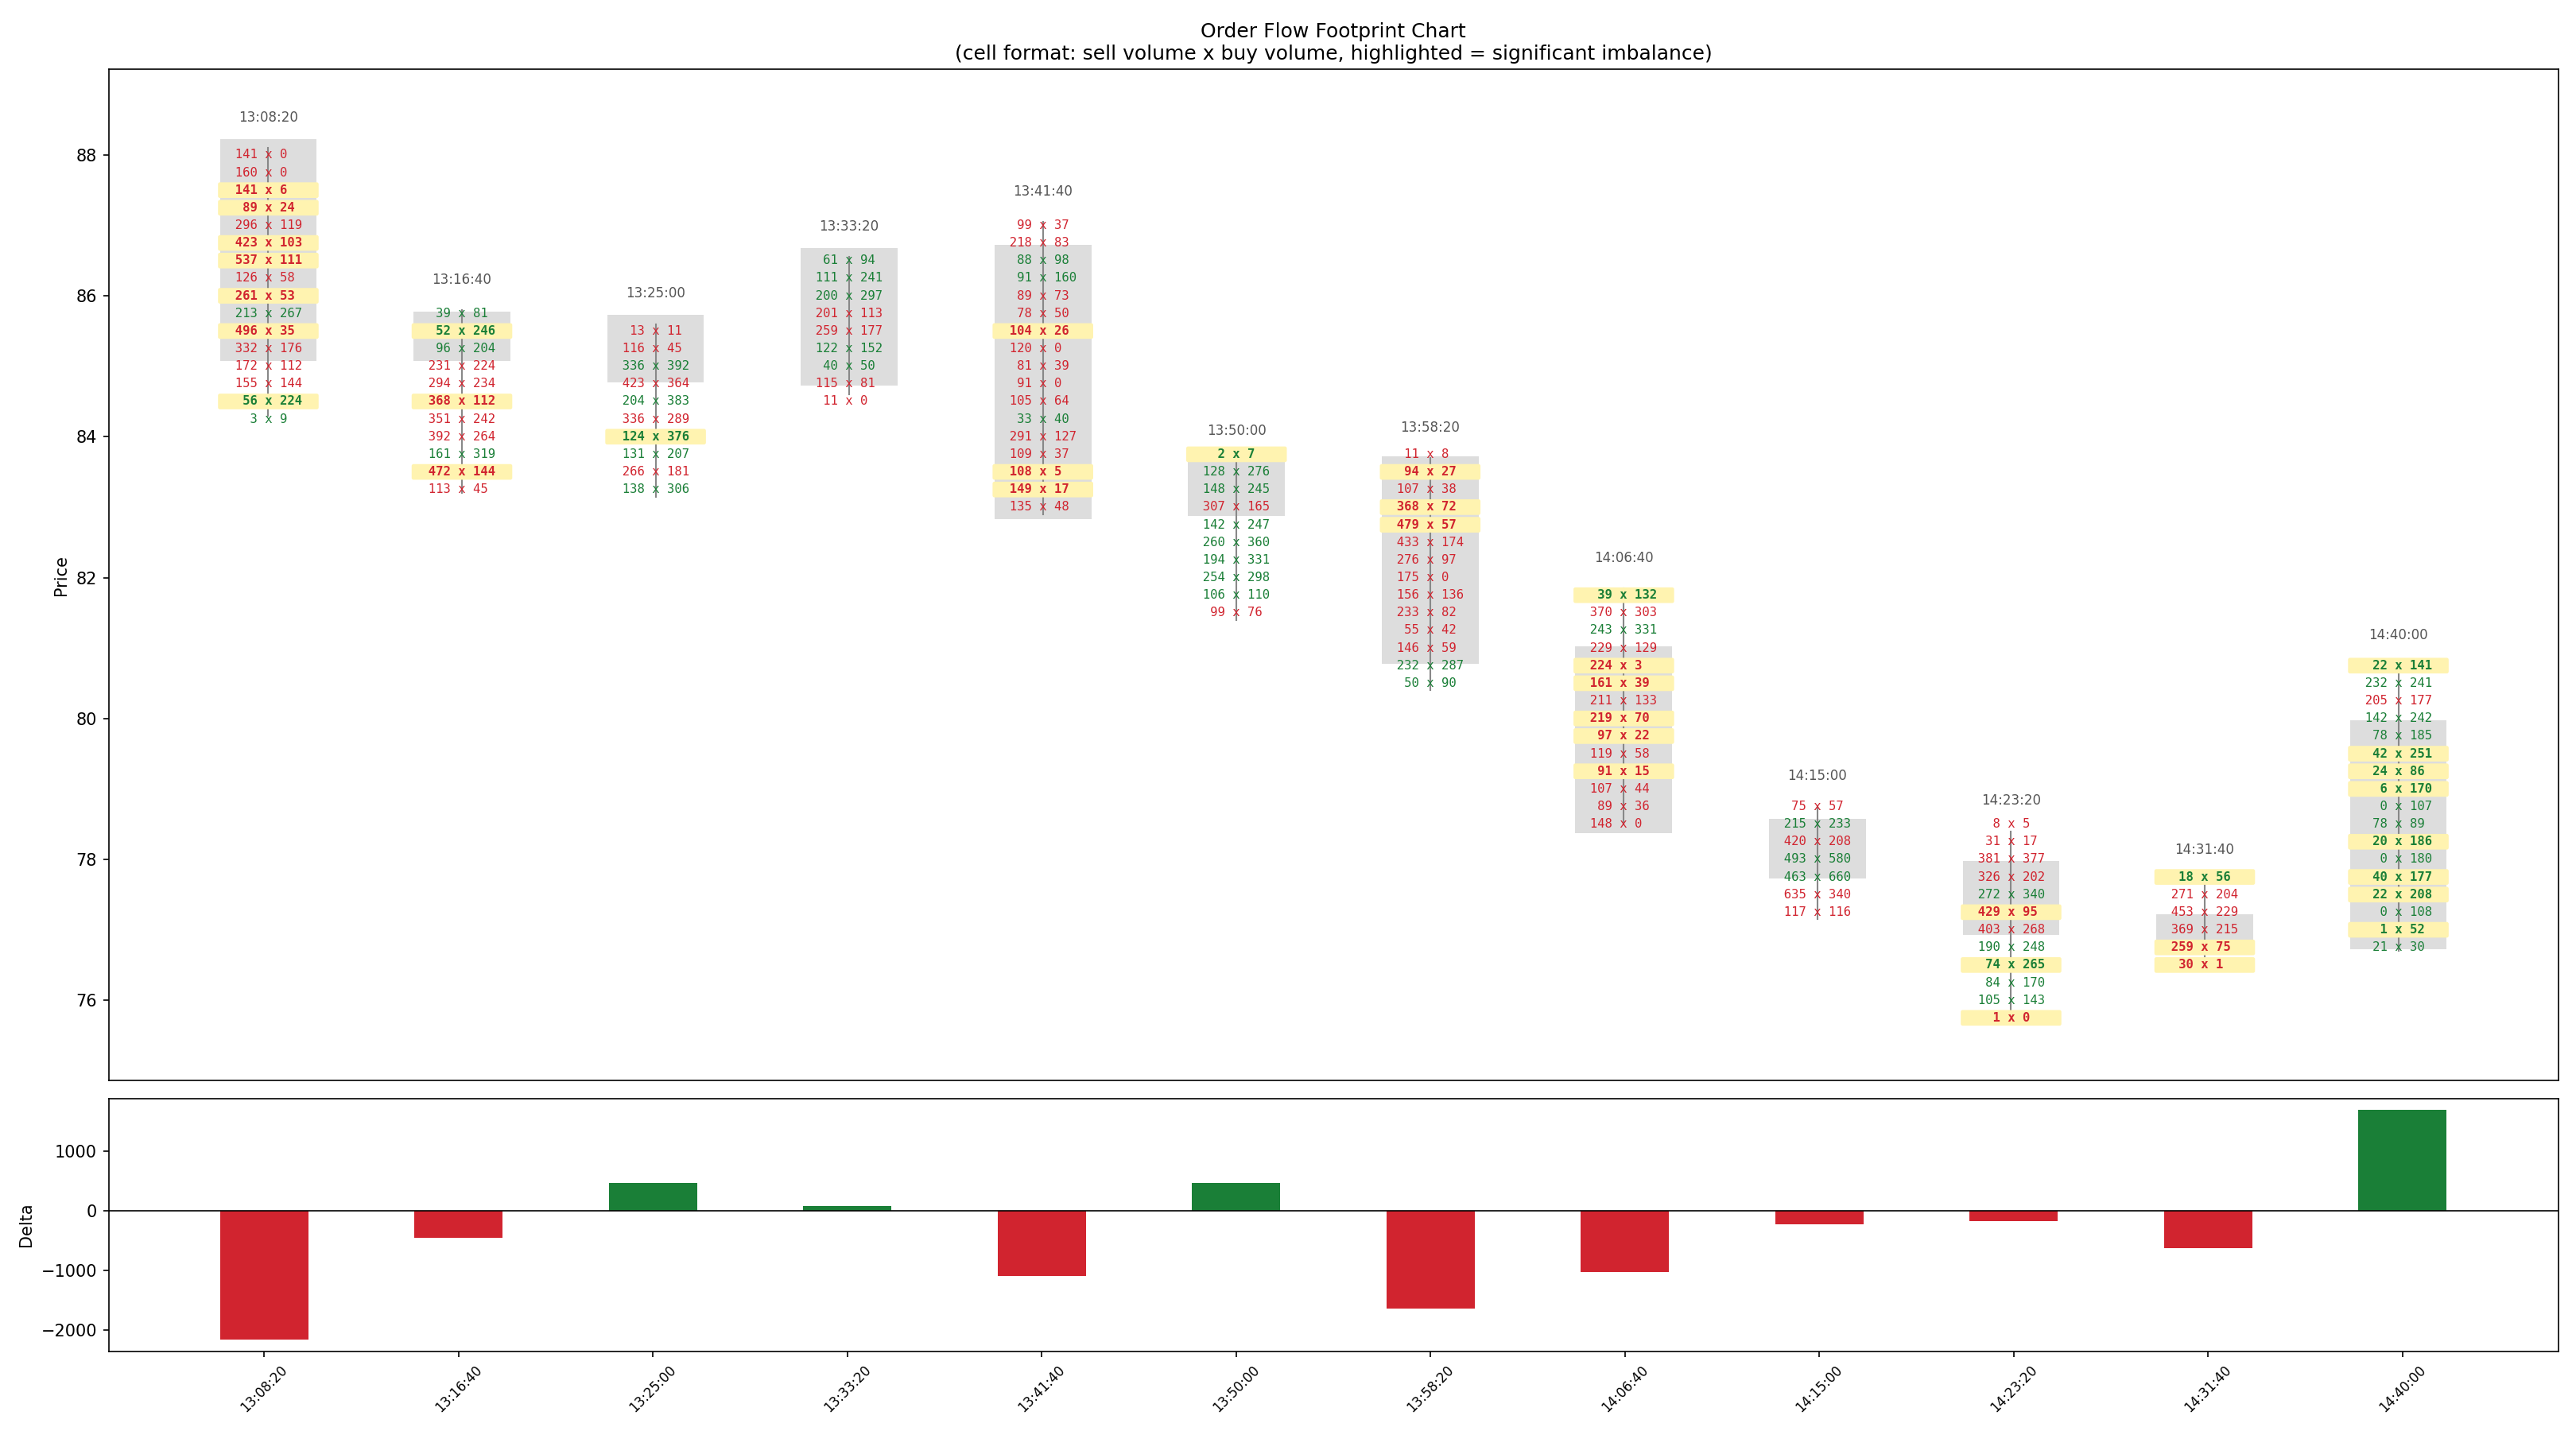

In [4]:
plot_footprint(candles, max_candles=12, save_path='/tmp/nb_footprint.png')
display(Image(filename='/tmp/nb_footprint.png'))

## 4. Price vs. cumulative delta

Divergence between price and cumulative delta (price up, delta flat/down) is a classic order-flow warning sign.

Saved chart to /tmp/nb_cumdelta.png


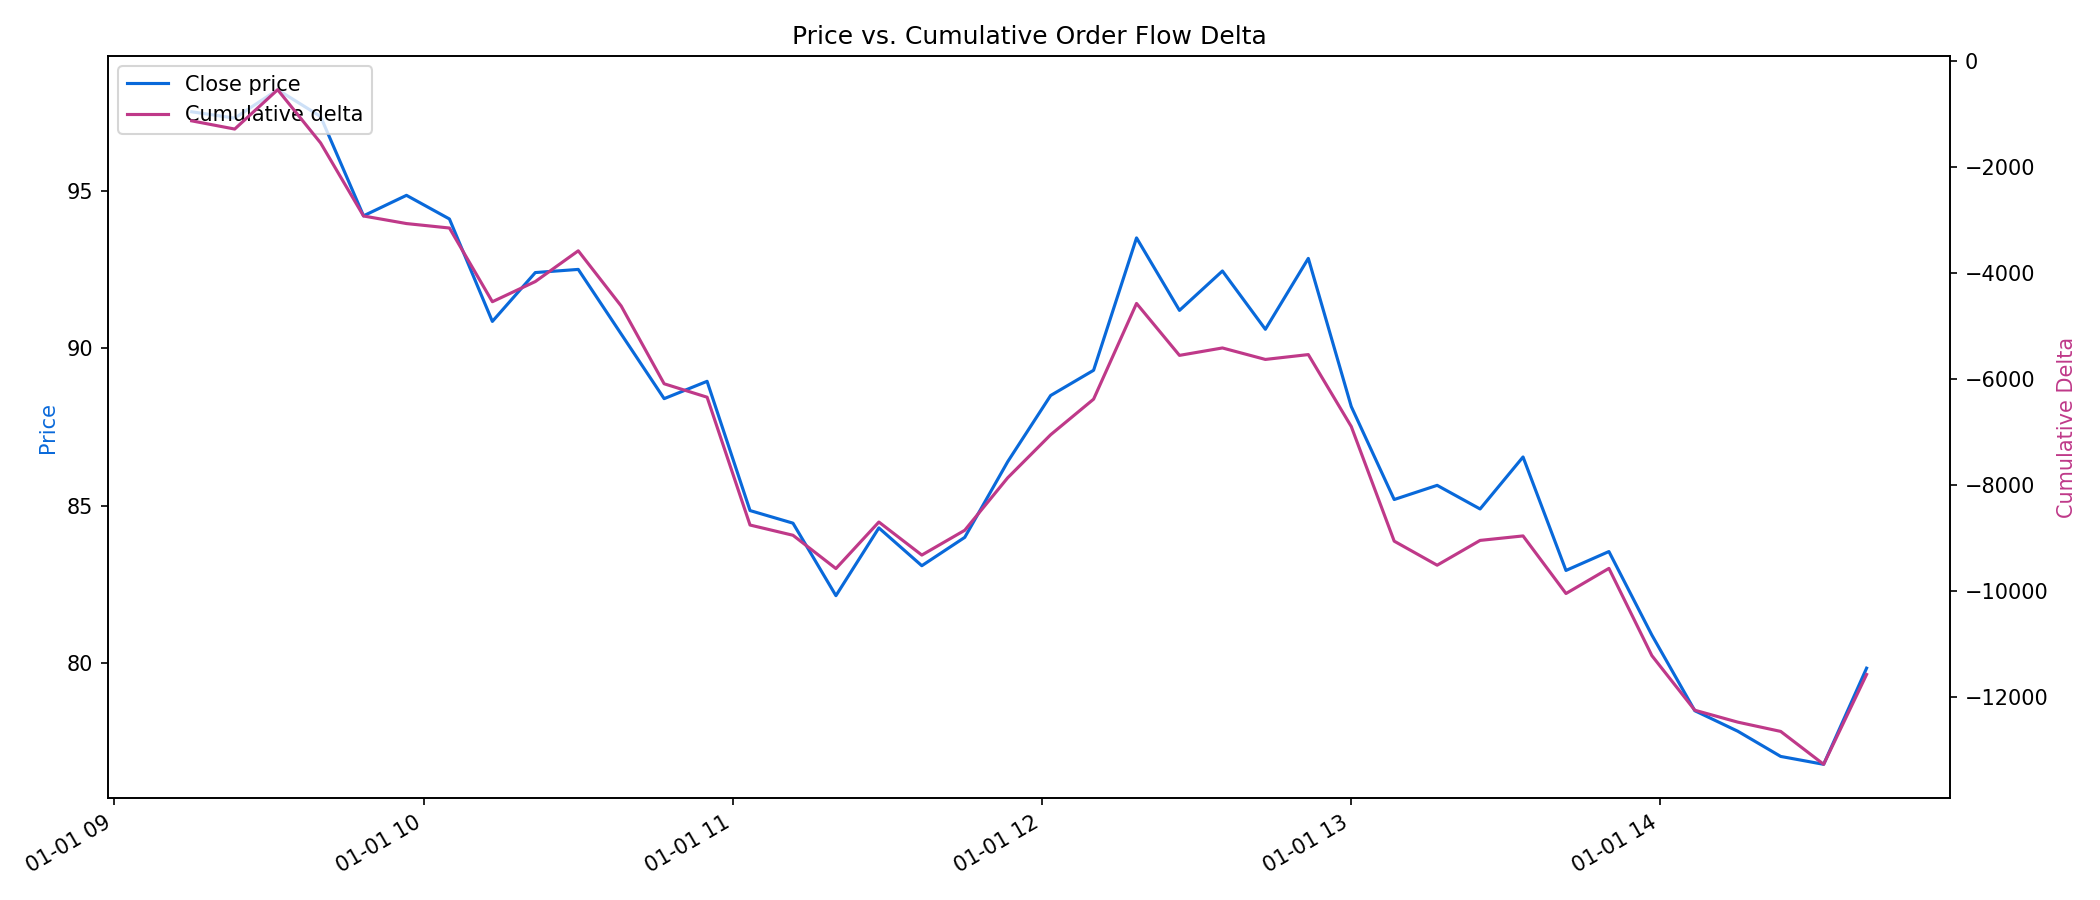

In [5]:
plot_cumulative_delta(candles, save_path='/tmp/nb_cumdelta.png')
display(Image(filename='/tmp/nb_cumdelta.png'))

## 5. Absorption/exhaustion detection

Flags candles where heavy one-sided aggression at the high/low fails to
push price through -- a classic reversal signal.

In [6]:
events = detect_absorption_events(candles)
print(events_to_report(events))

13 absorption event(s) detected:

  [2026-01-01 09:31:40] candle #2 @ 100.25 -- buying absorbed near highs (bearish signal) (sell 28 x buy 207, close 98.20 -> next close 97.35)
  [2026-01-01 10:05:00] candle #6 @ 95.75 -- buying absorbed near highs (bearish signal) (sell 35 x buy 195, close 94.10 -> next close 90.85)
  [2026-01-01 10:13:20] candle #7 @ 91.25 -- selling absorbed near lows (bullish signal) (sell 114 x buy 25, close 90.85 -> next close 92.40)
  [2026-01-01 10:46:40] candle #11 @ 88.50 -- selling absorbed near lows (bullish signal) (sell 118 x buy 5, close 88.40 -> next close 88.95)
  [2026-01-01 11:45:00] candle #18 @ 82.00 -- selling absorbed near lows (bullish signal) (sell 13 x buy 0, close 84.00 -> next close 86.40)
  [2026-01-01 12:35:00] candle #24 @ 92.75 -- buying absorbed near highs (bearish signal) (sell 3 x buy 11, close 92.45 -> next close 90.60)
  [2026-01-01 13:16:40] candle #29 @ 85.50 -- buying absorbed near highs (bearish signal) (sell 52 x buy 246, close

Saved chart to /tmp/nb_absorption.png


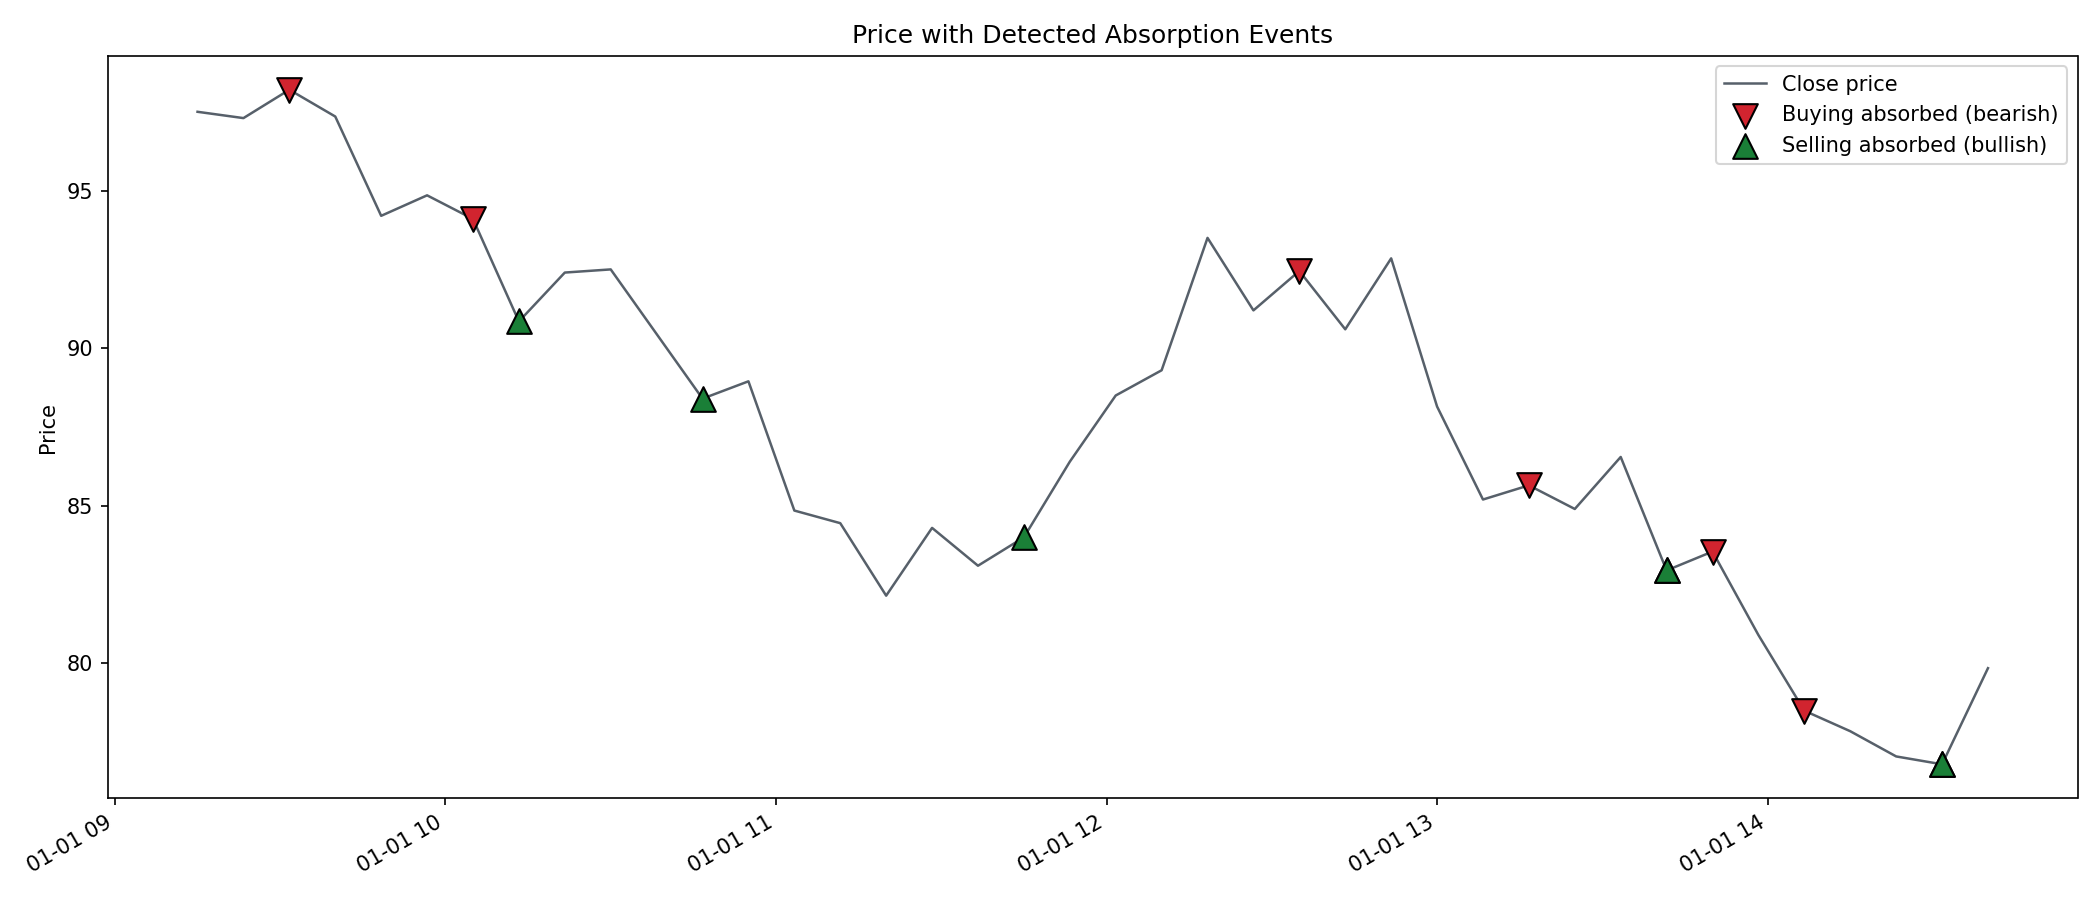

In [7]:
plot_absorption_events(candles, events, save_path='/tmp/nb_absorption.png')
display(Image(filename='/tmp/nb_absorption.png'))

## 6. Backtest the signal

Long on a bullish absorption event, short on a bearish one, fixed holding
period. Intentionally simple -- no sizing, slippage, or fees -- to
demonstrate the evaluation methodology.

In [8]:
trades = backtest_absorption_strategy(candles, events, hold_candles=3)
metrics = compute_performance_metrics(trades)
print(metrics_to_report(metrics))
trades

Trades:            11
Win rate:          54.5%
Total return:      12.007%
Avg return/trade:  1.2202%
Sharpe per trade:  0.191
Max drawdown:      -12.025%


,entry_time,exit_time,direction,entry_price,exit_price,pct_return,event_type
0,2026-01-01 09:40:00,2026-01-01 10:05:00,short,98.20,94.10,0.041752,buying absorbed near highs (bearish signal)
1,2026-01-01 10:13:20,2026-01-01 10:38:20,short,94.15,90.45,0.039299,buying absorbed near highs (bearish signal)
2,2026-01-01 10:21:40,2026-01-01 10:46:40,long,90.90,88.40,-0.027503,selling absorbed near lows (bullish signal)
3,2026-01-01 10:55:00,2026-01-01 11:20:00,long,88.40,82.15,-0.070701,selling absorbed near lows (bullish signal)
4,2026-01-01 11:53:20,2026-01-01 12:18:20,long,84.00,93.50,0.113095,selling absorbed near lows (bullish signal)
5,2026-01-01 12:43:20,2026-01-01 13:08:20,short,92.40,85.20,0.077922,buying absorbed near highs (bearish signal)
6,2026-01-01 13:25:00,2026-01-01 13:50:00,short,85.60,83.55,0.023949,buying absorbed near highs (bearish signal)
7,2026-01-01 13:50:00,2026-01-01 14:15:00,long,83.00,77.85,-0.062048,selling absorbed near lows (bullish signal)
8,2026-01-01 13:50:00,2026-01-01 14:15:00,long,83.00,77.85,-0.062048,selling absorbed near lows (bullish signal)
9,2026-01-01 13:58:20,2026-01-01 14:23:20,short,83.60,77.05,0.078349,buying absorbed near highs (bearish signal)


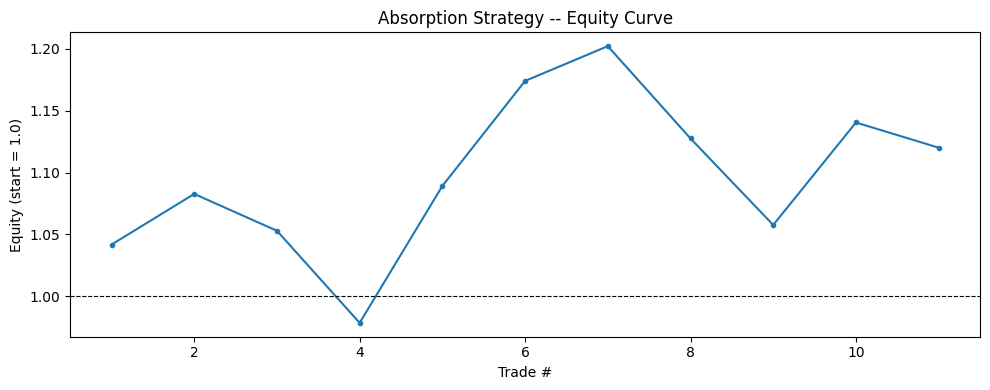

In [9]:
if not trades.empty:
    equity_curve = (1 + trades['pct_return']).cumprod()
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(range(1, len(equity_curve) + 1), equity_curve.values, marker='o', markersize=3)
    ax.axhline(1.0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Trade #'); ax.set_ylabel('Equity (start = 1.0)')
    ax.set_title('Absorption Strategy -- Equity Curve')
    plt.tight_layout(); plt.show()

## 7. Parameter sensitivity sweep

A single backtest result can just mean one lucky parameter combination.
This sweeps `imbalance_ratio` x `hold_candles` on the *same* tick data, so
differences across cells come from the parameters, not re-randomized data.

Saved heatmap to /tmp/nb_sweep.png


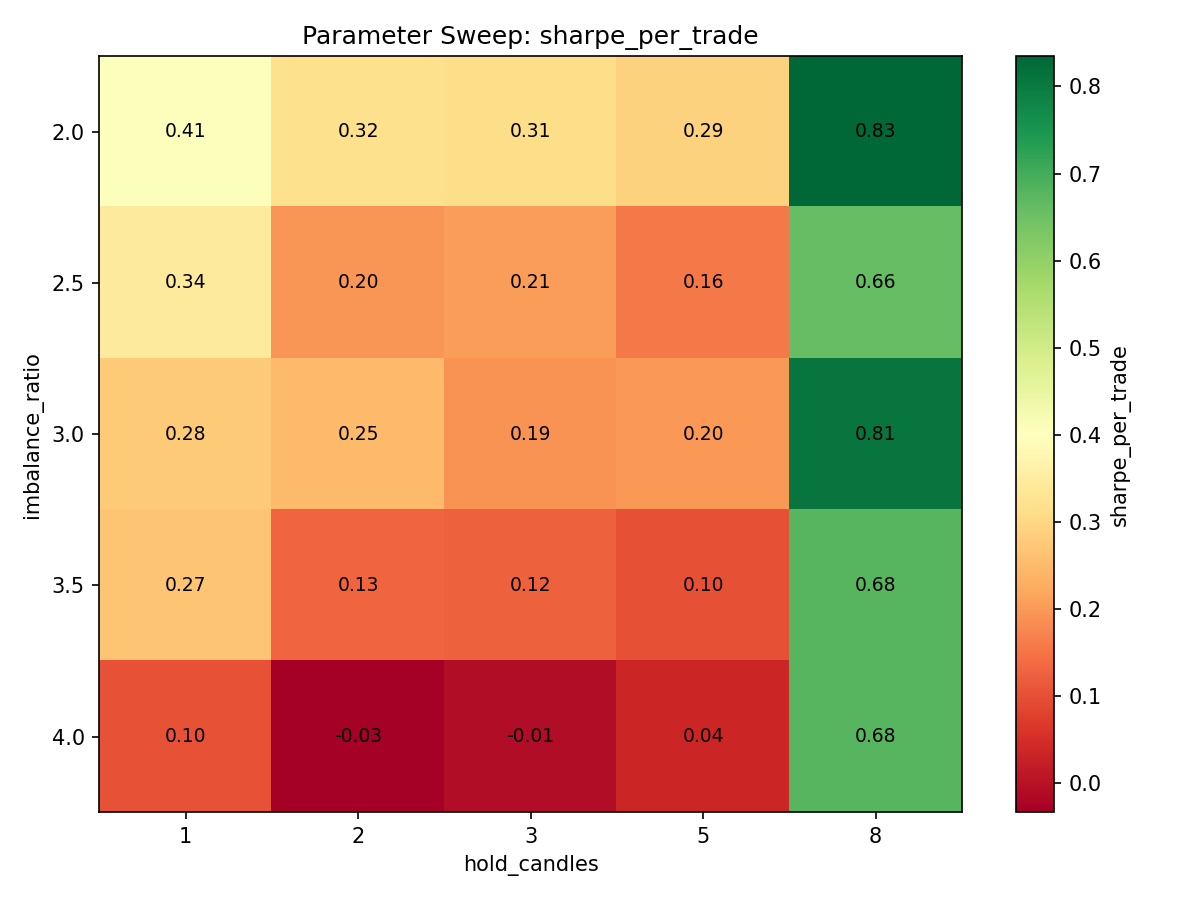

In [10]:
sweep_df = run_sweep(ticks, imbalance_ratios=(2.0, 2.5, 3.0, 3.5, 4.0), hold_candles_options=(1, 2, 3, 5, 8))
plot_sweep_heatmap(sweep_df, metric='sharpe_per_trade', save_path='/tmp/nb_sweep.png')
display(Image(filename='/tmp/nb_sweep.png'))

## Takeaways

- The footprint + delta view makes order-flow structure visible that a
  plain candlestick chart hides entirely.
- Absorption events are a plausible reversal signal, but the backtest here
  is deliberately simple (no fees/slippage/sizing) -- read the numbers as
  a demonstration of methodology, not a tradeable edge.
- The parameter sweep matters more than any single backtest number: a
  result that only shows up at one exact parameter value is a red flag
  for overfitting, and this sweep shows the strategy holds up reasonably
  across most of the grid except when the imbalance filter gets so strict
  that trade count drops into single digits.

See `README.md` for how to swap the simulated data for a real tick feed,
and `ARCHITECTURE.md` for the full module dependency diagram.